In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
r_s = 1
L = 10
b = 2

x0 = -L / 2
y0 = b

r0 = np.hypot(x0, y0)
phi0 = np.arctan2(y0, x0)
drdl0 = x0 / r0
dphidl0 = -y0 / r0**2
u0 = drdl0
L = r0**2 * dphidl0

x0, y0, r0, phi0, drdl0, dphidl0, u0, L

(-5.0,
 2,
 np.float64(5.385164807134504),
 np.float64(2.761086276477428),
 np.float64(-0.9284766908852594),
 np.float64(-0.06896551724137932),
 np.float64(-0.9284766908852594),
 np.float64(-2.0))

In [3]:
def f(y, r_s, L):
    r, u, phi = y
    drdl = u
    dudl = (r - 1.5 * r_s) * (L**2 / r**4)
    dphidl = L / r**2
    return np.array([drdl, dudl, dphidl])

def rk4_step(y, dl, r_s, L):
    k1 = f(y, r_s, L)
    k2 = f(y + 0.5 * dl * k1, r_s, L)
    k3 = f(y + 0.5 * dl * k2, r_s, L)
    k4 = f(y + dl * k3, r_s, L)
    return y + (dl / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

In [4]:
y = np.array([r0, u0, phi0], dtype=float)

dl = 1e-3
trajectory = [y.copy()]

for _ in tqdm(range(10000)):
    y = rk4_step(y, dl, r_s, L)
    trajectory.append(y.copy())
    if y[0] <= r_s:
        break

trajectory = np.array(trajectory)
r_vals = trajectory[:, 0]
phi_vals = trajectory[:, 2]

 55%|████████████████████████████████████████████████████▌                                           | 5479/10000 [00:00<00:00, 88597.48it/s]


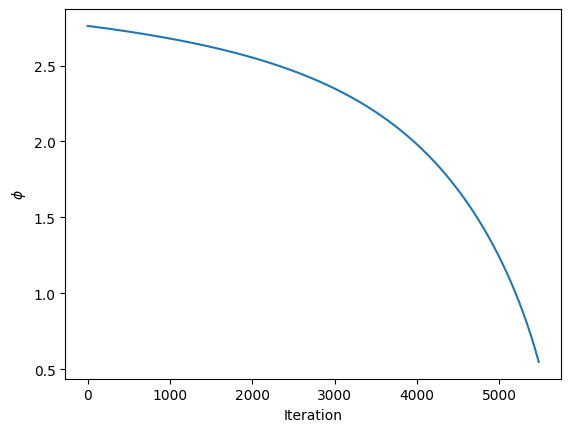

In [5]:
fig, ax = plt.subplots()

ax.plot(phi_vals)
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\phi$')

plt.show()

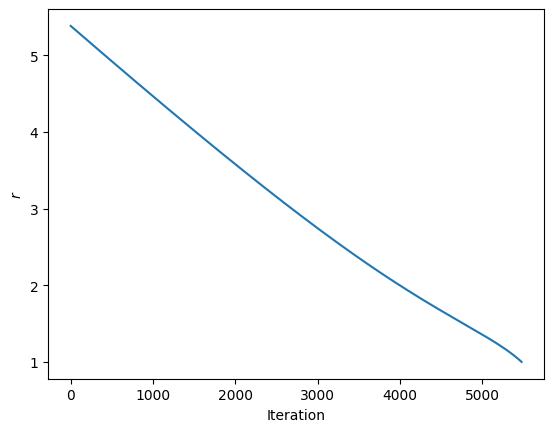

In [6]:
fig, ax = plt.subplots()

ax.plot(r_vals)
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$r$')

plt.show()

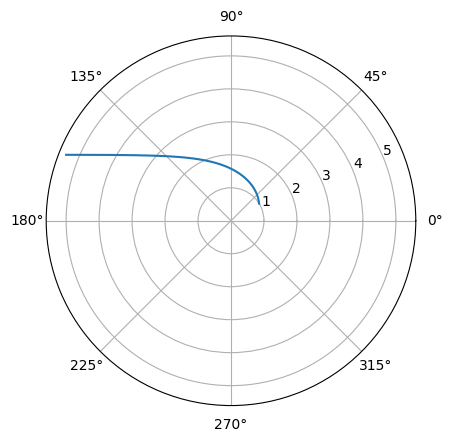

In [7]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

ax.plot(phi_vals, r_vals)

plt.show()